In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import torch
print(torch.__version__)

!pip install -U torch torchvision torchaudio
# Install common dependencies for Detectron2
!pip install opencv-python pycocotools
# Install Detectron2 from source to avoid wheel compatibility issues
!pip install 'git+https://github.com/facebookresearch/detectron2.git'

2.10.0+cu128
  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-7qirqkm2
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-7qirqkm2
  Resolved https://github.com/facebookresearch/detectron2.git to commit fd27788985af0f4ca800bca563acdb700bb890e2
  Preparing metadata (setup.py) ... done
  Using cached yacs-0.1.8-py3-none-any.whl.metadata (639 bytes)
  Using cached fvcore-0.1.5.post20221221.tar.gz (50 kB)
  Preparing metadata (setup.py) ... done
  Using cached iopath-0.1.9-py3-none-any.whl.metadata (370 bytes)
  Using cached hydra_core-1.3.2-py3-none-any.whl.metadata (5.5 kB)
  Using cached black-26.1.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (88 kB)
  Using cached portalocker-3.2.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached mypy_extensions-1.1.0-py3-none-any.whl.metadata (1.1 kB)
  Using cached pathspec-1.0.4-py3-none-any.whl.

In [2]:
import os
import cv2
import numpy as np
from detectron2.structures import BoxMode
from detectron2.data import DatasetCatalog, MetadataCatalog

# ===============================
# Paths
# ===============================
SYN_IMG_DIR = "/content/drive/MyDrive/embroidery_dataset/synthetic/images"
SYN_MASK_DIR = "/content/drive/MyDrive/embroidery_dataset/synthetic/masks"
ORG_IMG_DIR = "/content/drive/MyDrive/embroidery_dataset/originals/images"

# ===============================
# Mask → Polygon
# ===============================
def mask_to_polygons(mask, min_points=6):
    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    return [c.flatten().tolist() for c in contours if len(c) >= min_points]

# ===============================
# Combined Dataset
# ===============================
def embroidery_combined_dataset():
    dataset_dicts = []
    image_id = 0

    # -------- Synthetic (defects) --------
    for img_name in sorted(os.listdir(SYN_IMG_DIR)):
        img_path = os.path.join(SYN_IMG_DIR, img_name)
        base = os.path.splitext(img_name)[0]
        mask_path = os.path.join(SYN_MASK_DIR, base + "_mask.png")

        if not os.path.exists(mask_path):
            continue

        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path, 0)

        if img is None or mask is None or np.count_nonzero(mask) == 0:
            continue

        h, w = img.shape[:2]

        if "_overlap" in img_name:
            class_id = 0
        elif "_missing" in img_name:
            class_id = 1
        elif "_crease" in img_name:
            class_id = 2
        else:
            continue

        polygons = mask_to_polygons(mask)
        if len(polygons) == 0:
            continue

        ys, xs = np.where(mask > 0)
        x0, y0, x1, y1 = xs.min(), ys.min(), xs.max(), ys.max()

        dataset_dicts.append({
            "file_name": img_path,
            "image_id": image_id,
            "height": h,
            "width": w,
            "annotations": [{
                "bbox": [x0, y0, x1 - x0, y1 - y0],
                "bbox_mode": BoxMode.XYWH_ABS,
                "segmentation": polygons,
                "category_id": class_id
            }]
        })
        image_id += 1

    # -------- Original (clean) --------
    for img_name in sorted(os.listdir(ORG_IMG_DIR)):
        img_path = os.path.join(ORG_IMG_DIR, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue

        h, w = img.shape[:2]

        dataset_dicts.append({
            "file_name": img_path,
            "image_id": image_id,
            "height": h,
            "width": w,
            "annotations": []  # NO defects
        })
        image_id += 1

    print(f"Total images loaded: {len(dataset_dicts)}")
    return dataset_dicts

# ===============================
# Register Dataset
# ===============================
from detectron2.data import DatasetCatalog, MetadataCatalog

if "embroidery_train" in DatasetCatalog.list():
    DatasetCatalog.remove("embroidery_train")

DatasetCatalog.register(
    "embroidery_train",
    embroidery_combined_dataset
)

MetadataCatalog.get("embroidery_train").set(
    thing_classes=["overlap_stitch", "missing_stitch", "crease"]
)



namespace(name='embroidery_train',
          thing_classes=['overlap_stitch', 'missing_stitch', 'crease'])

In [27]:
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo

cfg = get_cfg()
cfg.merge_from_file(
    model_zoo.get_config_file(
        "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"
    )
)

cfg.MODEL.ROI_HEADS.NUM_CLASSES = 3
cfg.MODEL.WEIGHTS = "/content/drive/MyDrive/embroidery_dataset/output/model_final.pth"  # change path if needed
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.MODEL.DEVICE = "cuda"

predictor = DefaultPredictor(cfg)


proposal_generator.rpn_head.anchor_deltas.{bias, weight}
proposal_generator.rpn_head.objectness_logits.{bias, weight}


In [28]:
import cv2
from detectron2.utils.visualizer import Visualizer


img = cv2.imread("/content/drive/MyDrive/embroidery_dataset/0b9a704399543f33a0bcfedb5ad9a458.jpg_missing.png")
outputs = predictor(img)

instances = outputs["instances"].to("cpu")

print("Number of detections:", len(instances))


Number of detections: 2


⚠ Defect detected


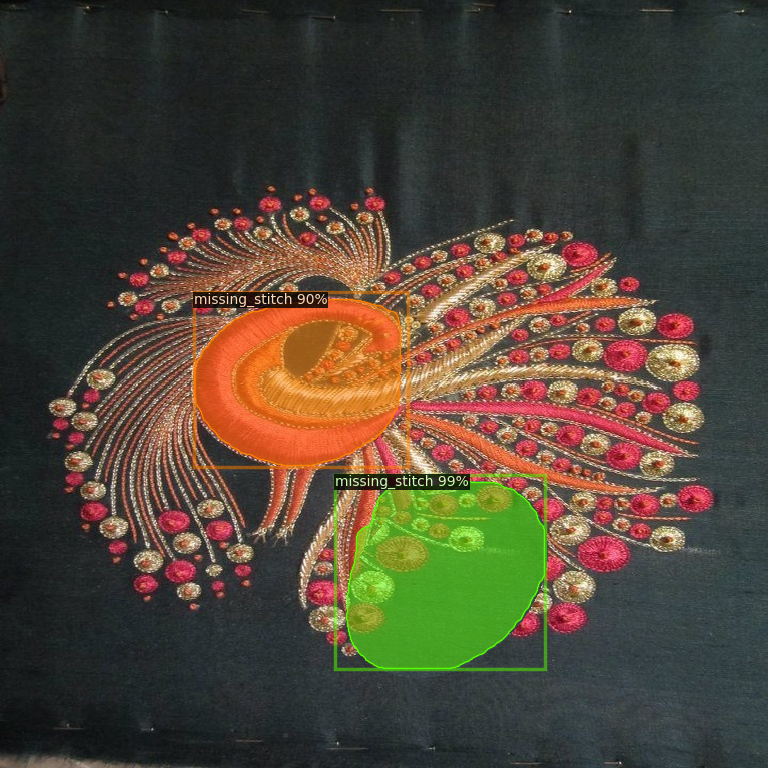

In [29]:
from detectron2.data import MetadataCatalog
from google.colab.patches import cv2_imshow # Import cv2_imshow

metadata = MetadataCatalog.get("embroidery_train")

if len(instances) == 0:
    print("✅ Image is clean — no defects detected")
    cv2_imshow(img) # Changed to cv2_imshow
else:
    print("⚠ Defect detected")
    v = Visualizer(img[:, :, ::-1], metadata, scale=1.0)
    out = v.draw_instance_predictions(instances)
    cv2_imshow(out.get_image()[:, :, ::-1]) # Changed to cv2_imshow

# cv2.waitKey(0) is not needed and can be removed in Colab context, as cv2_imshow displays the image directly.

In [30]:
for i in range(len(instances)):
    cls = instances.pred_classes[i].item()
    score = instances.scores[i].item()
    print(f"Detection {i+1}: Class={metadata.thing_classes[cls]}, Score={score:.3f}")


Detection 1: Class=missing_stitch, Score=0.986
Detection 2: Class=missing_stitch, Score=0.900


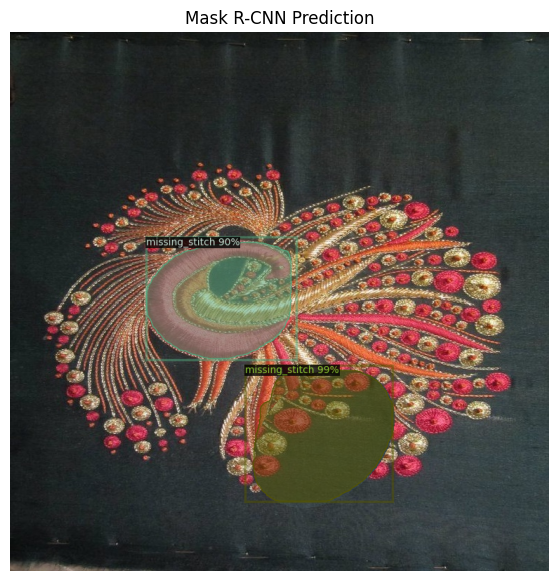

In [31]:
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog

metadata = MetadataCatalog.get("embroidery_train")

v = Visualizer(
    img[:, :, ::-1],
    metadata=metadata,
    scale=1.0
)

out = v.draw_instance_predictions(instances)

plt.figure(figsize=(7,7))
plt.imshow(out.get_image())
plt.title("Mask R-CNN Prediction")
plt.axis("off")
plt.show()


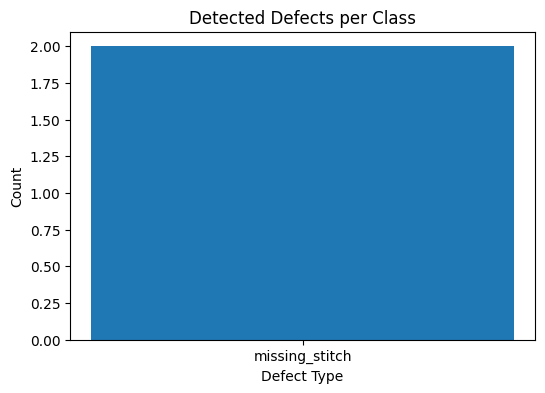

In [32]:
from collections import Counter

class_names = metadata.thing_classes
class_ids = instances.pred_classes.numpy() if len(instances) > 0 else []

counts = Counter(class_ids)

labels = [class_names[i] for i in counts.keys()]
values = [counts[i] for i in counts.keys()]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.xlabel("Defect Type")
plt.ylabel("Count")
plt.title("Detected Defects per Class")
plt.show()


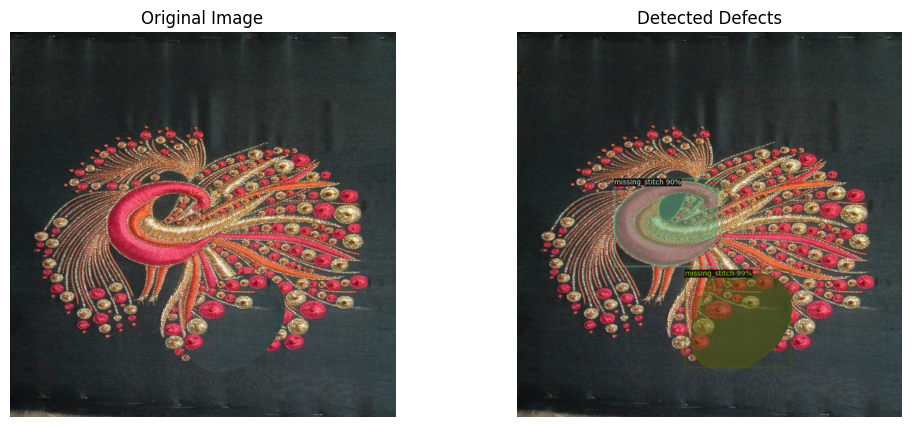

In [33]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img[:, :, ::-1])
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(out.get_image())
plt.title("Detected Defects")
plt.axis("off")

plt.show()
